# Task 1

See [AMO ch 16 + 17.4 in LMS] or the handwritten document `Notes_210428_114528.pdf`.

# Task 2 

We consider the following problem from (Fisher M., [An Applications Oriented Guide to Lagrangian Relaxation](http://www.cs.uleth.ca/~benkoczi/OR/read/lagrange-relax-introduct-fisher85.pdf) Interfaces, 15:2, 1985):

$$
\begin{array}{lllll}
 z_P=&\text{max} &16x_1+10x_2+4x_4\\
&\text{s.t.}&8x_1+2x_2+x_3+4x_4\leq 10\\
&&x_1+x_2\leq 1\\
&&x_3+x_4\leq 1\\
&&0\leq x\leq 1 \qquad \text{and integer}
\end{array}
$$

There are three major questions to design a Lagrangian-relaxation-based system:

- which constraints should be relaxed?
- how to compute good multipliers $\lambda$?
- how to deduce a good feasible solution to the original problem, given a solution to the Lagrangian relaxation problem?

The answers are:

- those whose relaxation makes the problem significantly easy but not too easy
- subgradient optimization procedure
- problem specific heuristics


## Subtask 2.1
If we relax the first constraint with multiplier $\lambda\geq 0$ the corresponding Lagrangian relaxation problem becomes:

$$
\begin{array}{lllll}
 z_{LR}=&\text{max} &(16-8\lambda)x_1+(10-2\lambda)x_2+(0-\lambda)x_3+(4-4\lambda)x_4+10\lambda\\
&\text{s.t.}&x_1+x_2\leq 1\\
&&x_3+x_4\leq 1\\
&&0\leq x\leq 1 \qquad \text{and integer}
\end{array}
$$


For a given $\lambda$ we could solve the problem by inspection: 
- between $x_1$ and $x_2$ set to 1 the variable with the largest cost coefficient in the objective function; 
- between $x_1$ and $x_2$ set to 1 the variable with the largest cost coefficient in the objective function.
However let's use the SCIP procedure developed above.

Lambda: 0, Lagrangian Relaxation Value: [20.  0.  0.  0.  0.  0.], Solution: [1 0 0 1]
Lambda: 0.5, Lagrangian Relaxation Value: [20. 19.  0.  0.  0.  0.], Solution: [1 0 0 1]
Lambda: 1, Lagrangian Relaxation Value: [20. 19. 18.  0.  0.  0.], Solution: [1 0 0 0]
Lambda: 2, Lagrangian Relaxation Value: [20. 19. 18. 26.  0.  0.], Solution: [0 1 0 0]
Lambda: 4, Lagrangian Relaxation Value: [20. 19. 18. 26. 42.  0.], Solution: [0 1 0 0]
Lambda: 8, Lagrangian Relaxation Value: [20. 19. 18. 26. 42. 80.], Solution: [0 0 0 0]
Lower bound: 18.0


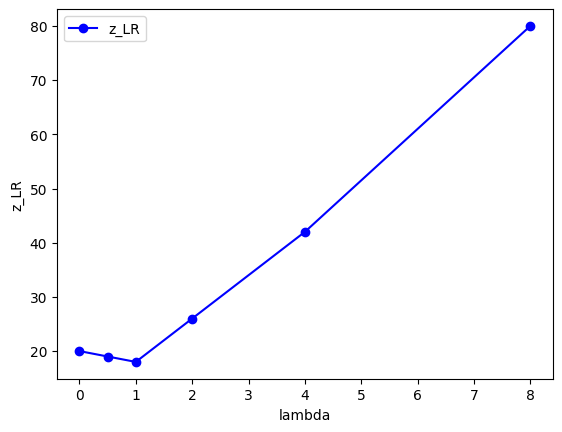

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import gurobipy as gp

c=np.array([16, 10, 0, 4])
b=np.array([10, 1, 1])  
A = np.array([[8, 2, 1, 4], [1, 1, 0, 0], [0, 0, 1, 1]])  

def solve_lagrangian_relaxation_1(c, A, b, lambdas: np.ndarray) -> np.ndarray:
    # c @ x - lambdas @ (A[0] @ x - b[0])
    # ensure lambdas is a scalar or broadcastable array
    lam = np.asarray(lambdas)
    coeff = c - lam * A[0]

    x = np.zeros_like(c, dtype=int)

    # first pair x1,x2
    idx = np.argmax(coeff[:2])          # 0 or 1
    if coeff[idx] > 0:                 # only take it if profitable
        x[idx] = 1

    # second pair x3,x4
    idx = 2 + np.argmax(coeff[2:4])    # 2 or 3
    if coeff[idx] > 0:
        x[idx] = 1

    return coeff @ x + lam * b[0], x

lambdas = [0, 0.5, 1, 2, 4, 8]
z_LR=np.zeros_like(lambdas)
for i, lam in enumerate(lambdas):
    z_LR[i], x_LR = solve_lagrangian_relaxation_1(c, A, b, lambdas=lam)
    print(f"Lambda: {lam}, Lagrangian Relaxation Value: {z_LR}, Solution: {x_LR}")

z_LD = np.min(z_LR)
print(f"Lower bound: {z_LD}")

plt.plot(lambdas, z_LR, marker='o',color='blue',label="z_LR")
plt.ylabel('z_LR')
plt.xlabel('lambda')
plt.legend()
plt.show()




The LD bound is the same as the LP bound. This is because the Lagrangian
relaxation problem has the integrality property. 
In conclusion with this relaxation we do not gain anything in bounding, but we gain
a solution process that can be considered easier (no LP involved).

## Subtask 2.2

In [2]:

def solve_lagrangian_relaxation_2(c, A, b, lambdas: np.ndarray) -> np.ndarray:
    lam = np.asarray(lambdas)
    try:
        m = gp.Model("knapsack")
        m.setParam(gp.GRB.Param.OutputFlag, 0)
        x = m.addMVar(shape=c.shape[0], vtype=gp.GRB.BINARY, name="x")

        coeff = c - lam @ A[1:3, ] 

        # Set objective
        m.setObjective(coeff @ x, gp.GRB.MAXIMIZE)

        # Add constraints
        m.addConstr(A[0,] @ x <= b[0], name="c")

        # Optimize model
        m.optimize()

        #print(x.X)
        #print('Obj: %g' % m.objVal)

    except gp.GurobiError as e:
        print('Error code ' + str(e.errno) + ": " + str(e))

    except AttributeError:
        print('Encountered an attribute error')

    return coeff @ x.X + lam @ b[1:3], x.X

In [3]:
solve_lagrangian_relaxation_2(c, A, b, lambdas=[11,0])

Set parameter Username
Set parameter LicenseID to value 2769428


Academic license - for non-commercial use only - expires 2027-01-23


(np.float64(16.0), array([1., 0., 0., 0.]))

In [4]:
def subgradient_iteration(c, A, b, lambdas, z_UB, epsilon=0.1, mu=2):
    z_LR, x = solve_lagrangian_relaxation_2(c, A, b, lambdas)
    subgradient = b[1:3] - A[1:3,] @ x
    if np.linalg.norm(subgradient)<0.002:
        return x, z_LR, subgradient, lambdas
    theta = mu * ( z_UB - z_LR )/(np.sum(subgradient**2))
    for i in range(lambdas.shape[0]):
        if (np.abs(subgradient[i])>epsilon):                
            lambdas[i] = max(lambdas[i] + theta * subgradient[i], 0)
    print(f"subgradient: {subgradient}, step: {subgradient*theta}, lambdas: {lambdas}, z_LR: {z_LR}")
    return x, z_LR, subgradient, lambdas

subgradient_iteration(c, A, b, np.array([11,0]), z_UB=16)

subgradient_iteration(c, A, b, np.array([2,2]), z_UB=16)



subgradient: [0. 1.], step: [0. 0.], lambdas: [11  0], z_LR: 16.0
subgradient: [-1.  1.], step: [ 10. -10.], lambdas: [12  0], z_LR: 26.0


(array([1., 1., 0., 0.]), np.float64(26.0), array([-1.,  1.]), array([12,  0]))

subgradient: [0. 1.], step: [ -0. -20.], lambdas: [10  0], z_LR: 26.0
mu halved
subgradient: [0. 1.], step: [0. 0.], lambdas: [10  0], z_LR: 16.0
subgradient: [0. 1.], step: [0. 0.], lambdas: [10  0], z_LR: 16.0
subgradient: [0. 1.], step: [0. 0.], lambdas: [10  0], z_LR: 16.0
subgradient: [0. 1.], step: [0. 0.], lambdas: [10  0], z_LR: 16.0
subgradient: [0. 1.], step: [0. 0.], lambdas: [10  0], z_LR: 16.0
mu halved
subgradient: [0. 1.], step: [0. 0.], lambdas: [10  0], z_LR: 16.0
subgradient: [0. 1.], step: [0. 0.], lambdas: [10  0], z_LR: 16.0
subgradient: [0. 1.], step: [0. 0.], lambdas: [10  0], z_LR: 16.0
subgradient: [0. 1.], step: [0. 0.], lambdas: [10  0], z_LR: 16.0


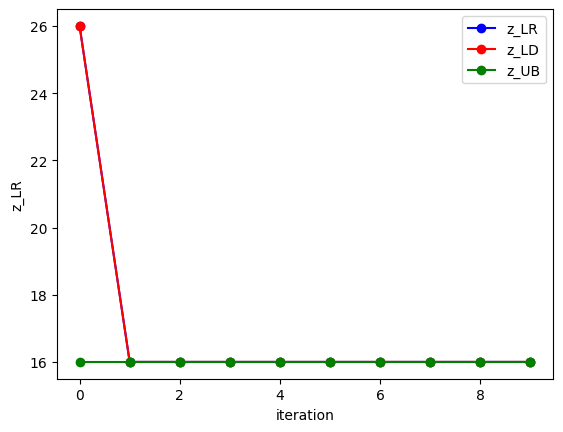

In [5]:
import math

iterations=10

z_LR=np.zeros(iterations)
z_LD=np.zeros(iterations)
# z_HR=np.zeros(iterations,dtype='float')
z_UB=np.zeros(iterations+1,dtype='float')
lambdas = np.array([10,10])
_lambdas = [lambdas]
z_LD[-1]=math.inf #float('-inf')
z_UB[0]=16
mu=2

for t in range(iterations):
    #print(_lambdas)
    x, z_LR[t], subgradient, lambdas = subgradient_iteration(c, A, b, lambdas, z_UB[t])
    if np.linalg.norm(subgradient)<0.002:
        iterations=t
        break
    
    z_LD[t] = min(z_LR[t],z_LD[t-1])
    z_UB[t+1] = z_UB[t]
    _lambdas.append(lambdas.copy())
    if t % math.ceil(iterations/2) == 0:
        print("mu halved")
        mu=mu/2

plt.plot(range(iterations), z_LR[:iterations], marker='o',color='blue',label="z_LR")
plt.plot(range(iterations), z_LD[:iterations], marker='o',color='red',label="z_LD")
plt.plot(range(iterations), z_UB[:iterations], marker='o',color='green',label="z_UB")
plt.ylabel('z_LR')
plt.xlabel('iteration')
plt.legend()
plt.show()

The LD bound is 16 while the LP bound is 18. Hence we obtain a better bound.
With this relaxation the Lagrangian subproblem does not have the integrality
property. The problem becomes a knapsack problem, that can be still solved
efficiently by dynamic programming (although here we used integer linear
programming) but less efficiently than with the relaxation from the previous
subtask. 